<a href="https://colab.research.google.com/github/Akesh-28/scikit_learn/blob/main/transaction_regressor_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dataset Loading**

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing  import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

df=pd.read_csv('Titanic-Dataset.csv')

*Feature & Target Selection*

In [ ]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [ ]:
impute=SimpleImputer(strategy='median')
df['Age']=impute.fit_transform(df[['Age']])
df['Age'].isnull().sum()

np.int64(0)

*Categorical Encoding & Preprocessing Pipeline*

In [ ]:
enc=OneHotEncoder(sparse_output=False)
df['Sex']=enc.fit_transform(df[['Sex']])
df['Embarked']=enc.fit_transform(df[['Embarked']])
enc.get_feature_names_out()

array(['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_nan'],
      dtype=object)

*Train-Test Split*

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
num_f=['Age', 'Fare', 'SibSp']
cat_f=["Sex","Embarked"]

prep=ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_f),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(drop='first',sparse_output=False, handle_unknown='ignore'))]), cat_f)
    ],
    remainder='drop'
)
prep.set_output(transform="pandas")
X_train_trans=prep.fit_transform(X_train)
X_test_trans=prep.transform(X_test)
print(X_train_trans.head())

     num__Age  num__Fare  num__SibSp  cat__Sex_male  cat__Embarked_Q  \
331  1.253641  -0.078684   -0.470722            1.0              0.0   
733 -0.477284  -0.377145   -0.470722            1.0              0.0   
382  0.215086  -0.474867   -0.470722            1.0              0.0   
704 -0.246494  -0.476230    0.379923            1.0              0.0   
813 -1.785093  -0.025249    2.931860            0.0              0.0   

     cat__Embarked_S  
331              1.0  
733              1.0  
382              1.0  
704              1.0  
813              1.0  


**Logistic Regression Model & Random Forest Model**

In [ ]:

pipe=Pipeline([('preprocessor',prep),('l_model',LogisticRegression(max_iter=1000))])
pipe.fit(X_train,y_train)
pred=pipe.predict(X_test)
pipe_r=Pipeline([('preprocessor',prep),('r_model',RandomForestClassifier(random_state=42))])
pipe_r.fit(X_train,y_train)
pred_r=pipe_r.predict(X_test)

**Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:")
print(classification_report(y_test, pred))

print("Random Forest Report:")
print(classification_report(y_test, pred_r))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       105
           1       0.76      0.70      0.73        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

Random Forest Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



*Accuracy Comparison*

In [ ]:
print(f"Lrs:{pipe.score(X_test,y_test)}")
print(f"Rfs:{pipe_r.score(X_test,y_test)}")

Lrs:0.7877094972067039
Rfs:0.7932960893854749


**Confusion Matrix**

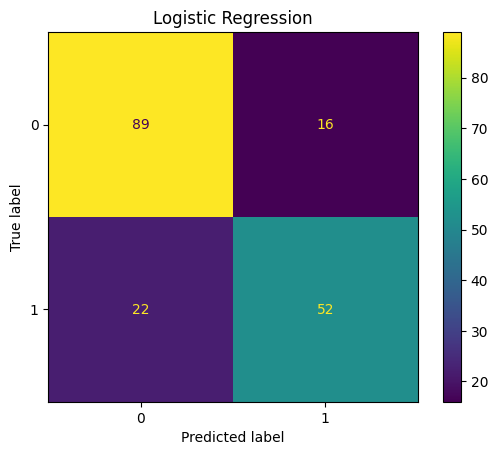

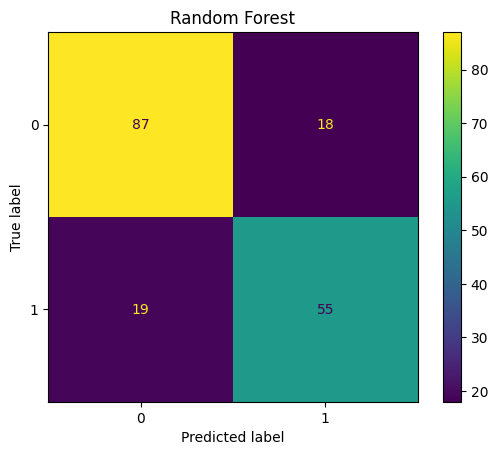

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test)
plt.title("Logistic Regression")

ConfusionMatrixDisplay.from_estimator(pipe_r, X_test, y_test)
plt.title("Random Forest")
plt.show()


***Random Forest Hyperparameter Tuning***

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

pram={
    'n_estimators':[1,2,3],
    'max_depth':[None,2,1],
    'min_samples_split':[2,5]
    }
grid=GridSearchCV(RandomForestClassifier(),pram,cv=5)

grid.fit(X_train_trans,y_train)
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 2}


In [ ]:
dff